# Top anomalies to explain in parallel

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anomaly.utils import specobjid_to_idx

from astroExplain.spectra.explanation import ingest_explanations_into_array
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

# Config

## Residuals

In [2]:
se_family = ["mse", "mse_97", "mse_filter_250", "mse_filter_250_97"]
rse_family = [f"{col}_rel" for col in se_family]
se_and_rse_family = se_family + rse_family

## Directories

In [3]:
phd_dir = "/home/elom/phd"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
explanations_dir = f"{data_dir}/explanations"
latent_dir = f"{data_dir}/latent"

## Data

In [4]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Scores

In [5]:
bin_id = "bin_03"
scores_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col="specobjid",
)

iforest_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/iforest/" f"iforest_scores_{bin_id}_s128_e300_f100.csv",
    index_col="specobjid",
)

lof_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/lof/" f"lof_scores_{bin_id}_n60_manhattan.csv",
    index_col="specobjid",
)

# Residual based scores

In [14]:
scores_df.columns

Index(['mse_rel', 'mse_filter_250_97_rel', 'mse_95', 'mse_97_rel', 'mse',
       'mse_97', 'mse_filter_250_95_rel', 'mse_filter_300_95', 'mse_95_rel',
       'mse_filter_300', 'mse_filter_250_97', 'mse_filter_300_95_rel',
       'mse_filter_250', 'mse_filter_300_97', 'mse_filter_250_95',
       'mse_filter_300_97_rel', 'mse_filter_300_rel', 'mse_filter_250_rel'],
      dtype='object')

```python
objid_top_anomalies = {}
spec_top_anomalies = {}
bin_id = "bin_03"

for score in se_and_rse_family:

    save_to = f"{explanations_dir}/{bin_id}/{score}"
    os.makedirs(save_to, exist_ok=True)

    top_1_threshold = scores_df[score].quantile(0.99)
    top_1_mask = scores_df[score] >= top_1_threshold
    n_top_1 = top_1_mask.sum()

    print(f"Save {n_top_1} anomalies for {score} at:\n{save_to}")

    objids = scores_df[top_1_mask].index.to_numpy()
    objid_top_anomalies[score] = objids
    indices = [specobjid_to_idx(specid, idx_id_spec) for specid in objids]
    spec_top_anomalies[score] = spectra[indices]
    # save spectra and objids for top anomalies
    np.save(f"{save_to}/specobjids_anomalies.npy", objids)
    np.save(f"{save_to}/spectra_anomalies.npy", spectra[indices])
spec_top_anomalies[score].shape
```

# Iforest

In [38]:
iforest_df.head()

,raw_score,iforest_score,rank
specobjid,,,
1437819582281705472,0.071548,0.322118,25316
1792473383787587584,0.153484,0.094256,168380
1566270578824865792,0.166304,0.058604,178772
1833056640966879232,0.096127,0.253764,57815
2824940385879484416,0.129536,0.160855,126503


```python
bin_id = "bin_03"

save_to = f"{explanations_dir}/{bin_id}/iforest"
os.makedirs(save_to, exist_ok=True)

top_1_threshold = iforest_df["iforest_score"].quantile(0.99)
top_1_mask = iforest_df["iforest_score"] >= top_1_threshold
n_top_1 = top_1_mask.sum()

print(f"Save {n_top_1} anomalies for iforest at:\n{save_to}")

iforest_objids = iforest_df[top_1_mask].index.to_numpy()
indices = [specobjid_to_idx(specid, idx_id_spec) for specid in iforest_objids]
spec_anomalies_iforest = spectra[indices]
# save spectra and objids for top anomalies
np.save(f"{save_to}/specobjids_anomalies.npy", iforest_objids)
np.save(f"{save_to}/spectra_anomalies.npy", spec_anomalies_iforest)
```

## Test

```python
bin_id = "bin_03"
save_to = f"{explanations_dir}/{bin_id}/iforest"

test_iforest_objids = np.array(
    [1928785351883646976, 749873288389355520, 2390364730700097536, 694769887481980928]
)

test_indices = [specobjid_to_idx(specid, idx_id_spec) for specid in test_iforest_objids]
test_spec_iforest = spectra[test_indices]

np.save(f"{save_to}/test_specobjids_anomalies.npy", test_iforest_objids)
np.save(f"{save_to}/test_spectra_anomalies.npy", test_spec_iforest)
```

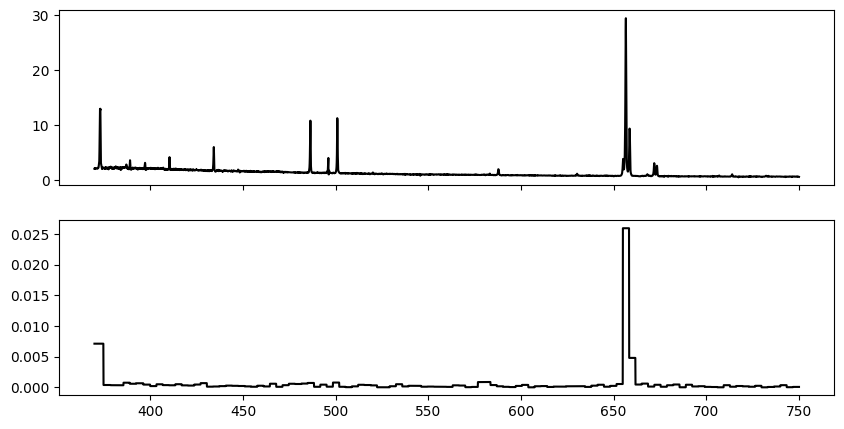

In [ ]:
xai_run_id = "xai_202606202305_uniform_110_samples_20000_scale_0.9"

test_iforest_specobjids = np.load(
    f"{explanations_dir}/{bin_id}/iforest/test_specobjids_anomalies.npy"
)
test_iforest_spectra = np.load(
    f"{explanations_dir}/{bin_id}/iforest/test_spectra_anomalies.npy"
)

iforest_weights_test = ingest_explanations_into_array(
    specobjids_array=test_iforest_specobjids,
    wave=wave,
    load_from_dir=f"{explanations_dir}/{bin_id}/iforest/{xai_run_id}",
)

abs_weights_all = np.abs(iforest_weights_test)

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
idx = 3
axs[0].plot(wave_nm, test_iforest_spectra[idx], color="black")
axs[1].plot(wave_nm, abs_weights_all[idx], color="black")

# LOF

In [43]:
lof_df.sort_values("lof", ascending=False).head()

,neg_lof,lof,rank
specobjid,,,
969534273977608192,-3.056807,1.000000,1
2930814289679771648,-2.913354,0.953071,2
2245159102839810048,-2.851112,0.932709,3
1071977423131666432,-2.731193,0.893479,4
1919783100783552512,-2.624299,0.858510,5


In [44]:
bin_id = "bin_03"

save_to = f"{explanations_dir}/{bin_id}/lof"
os.makedirs(save_to, exist_ok=True)

top_1_threshold = lof_df["lof"].quantile(0.99)
top_1_mask = lof_df["lof"] >= top_1_threshold
n_top_1 = top_1_mask.sum()

print(f"Save {n_top_1} anomalies for lof at:\n{save_to}")

lof_objids = lof_df[top_1_mask].index.to_numpy()
indices = [specobjid_to_idx(specid, idx_id_spec) for specid in lof_objids]
spec_anomalies_lof = spectra[indices]
# save spectra and objids for top anomalies
np.save(f"{save_to}/specobjids_anomalies.npy", lof_objids)
np.save(f"{save_to}/spectra_anomalies.npy", spec_anomalies_lof)

Save 1819 anomalies for lof at:
/home/elom/phd/code/explanations/bin_03/lof


In [49]:
lof_dict = {
    "evolved_H_alpha": 2501842015717713920,
    "evolved_sf": 873872364331362304,
    "weird_blue_excess": 3243851847563241472,
    "emission_line": 656537668875741184,
}
bin_id = "bin_03"
save_to = f"{explanations_dir}/{bin_id}/lof"

test_lof_objids = np.array(list(lof_dict.values()))

test_indices = [specobjid_to_idx(specid, idx_id_spec) for specid in test_lof_objids]
test_spec_lof = spectra[test_indices]

np.save(f"{save_to}/test_specobjids_anomalies.npy", test_lof_objids)
np.save(f"{save_to}/test_spectra_anomalies.npy", test_spec_lof)

## Test

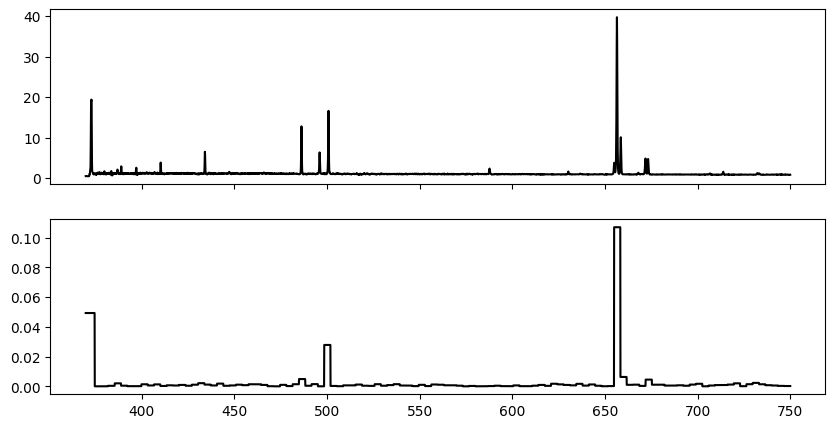

In [ ]:
xai_run_id = "xai_202606202312_uniform_110_samples_100000_scale_0.9"

test_lof_specobjids = np.load(
    f"{explanations_dir}/{bin_id}/lof/test_specobjids_anomalies.npy"
)
test_lof_spectra = np.load(
    f"{explanations_dir}/{bin_id}/lof/test_spectra_anomalies.npy"
)

lof_weights_test = ingest_explanations_into_array(
    specobjids_array=test_lof_specobjids,
    wave=wave,
    load_from_dir=f"{explanations_dir}/{bin_id}/lof/{xai_run_id}",
)

abs_weights_all = np.abs(lof_weights_test)

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
idx = 3
axs[0].plot(wave_nm, test_lof_spectra[idx], color="black")
axs[1].plot(wave_nm, abs_weights_all[idx], color="black")